# Day 10 — Classification Model Review & Loan Default Prediction

## Part A: Classification Model Review

This section validates the machine learning pipeline developed during the previous days.

The review focuses on:
- SMOTE implementation
- GridSearchCV configuration
- Classification metrics
- F1-score for imbalanced datasets
- Reproducibility
- Data leakage prevention

In [2]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("Random seed:", RANDOM_STATE)

Random seed: 42


In [3]:
print("SMOTE Leakage Check")
print("-" * 40)

print("SMOTE must be applied ONLY to:")
print("X_train and y_train")

print("\nSMOTE must NOT be applied to:")
print("X_test and y_test")

print("\nReason:")
print("The test set must remain completely unseen until final evaluation.")

SMOTE Leakage Check
----------------------------------------
SMOTE must be applied ONLY to:
X_train and y_train

SMOTE must NOT be applied to:
X_test and y_test

Reason:
The test set must remain completely unseen until final evaluation.


In [4]:
best_params = {
    "n_estimators": 50,
    "max_depth": 10,
    "min_samples_split": 2
}

cv_folds = 5

print("GridSearchCV Configuration")
print("-" * 40)

print("Best Parameters:", best_params)
print("Cross-validation folds:", cv_folds)

GridSearchCV Configuration
----------------------------------------
Best Parameters: {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 2}
Cross-validation folds: 5


## Classification Metrics

### Accuracy

Accuracy measures the percentage of total predictions that are correct.

Accuracy = (TP + TN) / (TP + TN + FP + FN)

### Precision

Precision measures how many predicted positive cases were actually positive.

Precision = TP / (TP + FP)

### Recall

Recall measures how many actual positive cases were correctly identified.

Recall = TP / (TP + FN)

### F1-Score

F1-score is the harmonic mean of Precision and Recall.

F1 = 2 × (Precision × Recall) / (Precision + Recall)

F1-score is particularly useful for imbalanced datasets because accuracy can hide poor performance on minority classes.

## Why Accuracy Can Be Misleading

In an imbalanced dataset, one class may contain far more observations than the other classes.

For example, if 95% of observations belong to one class, a model that always predicts the majority class could achieve approximately 95% accuracy while completely failing to identify the minority class.

Therefore, accuracy should not be used as the only evaluation metric.

Precision, Recall and F1-score provide a better understanding of classification performance, especially for minority classes.

## Data Leakage

Data leakage occurs when information from the test dataset influences model training.

Examples include:

1. Applying SMOTE before train-test splitting.
2. Fitting a scaler on the complete dataset before splitting.
3. Performing preprocessing using information from the test set.
4. Training the model using test observations.

Correct workflow:

Dataset
→ Train/Test Split
→ Fit preprocessing on training data
→ Apply preprocessing to training and test data
→ Apply SMOTE only to training data
→ Train model
→ Evaluate once on untouched test data

In [5]:
RANDOM_STATE = 42

print("Reproducibility settings")
print("-" * 40)
print("NumPy random_state:", RANDOM_STATE)
print("Train-test split:", RANDOM_STATE)
print("Random Forest:", RANDOM_STATE)
print("SMOTE:", RANDOM_STATE)

Reproducibility settings
----------------------------------------
NumPy random_state: 42
Train-test split: 42
Random Forest: 42
SMOTE: 42


## Part A Conclusion

The previous classification pipeline was reviewed for:

- Correct train-test separation
- SMOTE applied only to training data
- GridSearchCV using 5-fold cross-validation
- Optimized Random Forest parameters
- Accuracy, Precision, Recall and F1-score
- Reproducibility using random_state=42
- Prevention of data leakage

The most important evaluation metric for an imbalanced classification problem is not necessarily accuracy. F1-score provides a balance between Precision and Recall and is therefore particularly useful when both false positives and false negatives matter.

# Part B — Weekend Project

## Loan Default Prediction

### Objective

Build an end-to-end classification pipeline for predicting loan default.

The project includes:

- Data cleaning
- Exploratory inspection
- Train-test splitting
- Preprocessing
- Class imbalance handling
- Training three classification algorithms
- Classification metric comparison
- ROC-AUC evaluation
- ROC curve comparison
- Best model selection
- Model serialization

In [6]:
import pandas as pd

df = pd.read_csv("Loan_default.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (255347, 18)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [7]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum().sort_values(ascending=False))

Dataset Shape: (255347, 18)

Column Names:
['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']

Data Types:


LoanID                str
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education             str
EmploymentType        str
MaritalStatus         str
HasMortgage           str
HasDependents         str
LoanPurpose           str
HasCoSigner           str
Default             int64
dtype: object


Missing Values:


LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [9]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
LoanID,255347,255347,I38PQUQS96,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,255347.0,NaN,NaN,NaN,43.498306,14.990258,18.0,31.0,43.0,56.0,69.0
Income,255347.0,NaN,NaN,NaN,82499.304597,38963.013729,15000.0,48825.5,82466.0,116219.0,149999.0
LoanAmount,255347.0,NaN,NaN,NaN,127578.865512,70840.706142,5000.0,66156.0,127556.0,188985.0,249999.0
CreditScore,255347.0,NaN,NaN,NaN,574.264346,158.903867,300.0,437.0,574.0,712.0,849.0
MonthsEmployed,255347.0,NaN,NaN,NaN,59.541976,34.643376,0.0,30.0,60.0,90.0,119.0
NumCreditLines,255347.0,NaN,NaN,NaN,2.501036,1.117018,1.0,2.0,2.0,3.0,4.0
InterestRate,255347.0,NaN,NaN,NaN,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,NaN,NaN,NaN,36.025894,16.96933,12.0,24.0,36.0,48.0,60.0
DTIRatio,255347.0,NaN,NaN,NaN,0.500212,0.230917,0.1,0.3,0.5,0.7,0.9


In [10]:
TARGET = "Default"

print("Target column:", TARGET)

print("\nTarget counts:")
print(df[TARGET].value_counts())

print("\nTarget percentages:")
print((df[TARGET].value_counts(normalize=True) * 100).round(2))

Target column: Default

Target counts:
Default
0    225694
1     29653
Name: count, dtype: int64

Target percentages:
Default
0    88.39
1    11.61
Name: proportion, dtype: float64


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
df = df.drop_duplicates().reset_index(drop=True)

# LoanID is a unique identifier and should not be used as a predictive feature
df = df.drop(columns=["LoanID"])

print("Dataset shape after cleaning:", df.shape)
print("\nRemaining columns:")
print(df.columns.tolist())

Dataset shape after cleaning: (255347, 17)

Remaining columns:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


In [13]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (255347, 16)
y shape: (255347,)

Target distribution:
Default
0    225694
1     29653
Name: count, dtype: int64


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (204277, 16)
X_test shape: (51070, 16)
y_train shape: (204277,)
y_test shape: (51070,)


In [15]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTraining class percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting class distribution:")
print(y_test.value_counts())

print("\nTesting class percentages:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training class distribution:
Default
0    180555
1     23722
Name: count, dtype: int64

Training class percentages:
Default
0    88.39
1    11.61
Name: proportion, dtype: float64

Testing class distribution:
Default
0    45139
1     5931
Name: count, dtype: int64

Testing class percentages:
Default
0    88.39
1    11.61
Name: proportion, dtype: float64


In [16]:
# Identify numerical and categorical features

numeric_features = X_train.select_dtypes(
    include=['number']
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['str', 'object']
).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']
Categorical features: ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


In [17]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [18]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (204277, 31)
X_test_processed shape: (51070, 31)


In [19]:
print("Training Class Distribution:")
print(y_train.value_counts())

print("\nTraining Class Percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

Training Class Distribution:
Default
0    180555
1     23722
Name: count, dtype: int64

Training Class Percentages:
Default
0    88.39
1    11.61
Name: proportion, dtype: float64


In [20]:
from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully!")

SMOTE imported successfully!


In [21]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Original training shape:", X_train_processed.shape)
print("SMOTE training shape:", X_train_smote.shape)

print("\nClass distribution after SMOTE:")
print(y_train_smote.value_counts())

Original training shape: (204277, 31)
SMOTE training shape: (361110, 31)

Class distribution after SMOTE:
Default
0    180555
1    180555
Name: count, dtype: int64


In [22]:
from sklearn.ensemble import RandomForestClassifier

print("Random Forest imported successfully!")

Random Forest imported successfully!


In [23]:
best_params = {
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_split': 2
}

In [24]:
rf_model = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created!")

Random Forest model created!


In [25]:
rf_model.fit(
    X_train_smote,
    y_train_smote
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [26]:
y_pred = rf_model.predict(X_test_processed)

print("Predictions completed!")
print("Number of predictions:", len(y_pred))

Predictions completed!
Number of predictions: 51070


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.7914
Precision: 0.8493
Recall   : 0.7914
F1 Score : 0.8148


In [28]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.83      0.88     45139
           1       0.27      0.49      0.35      5931

    accuracy                           0.79     51070
   macro avg       0.60      0.66      0.61     51070
weighted avg       0.85      0.79      0.81     51070



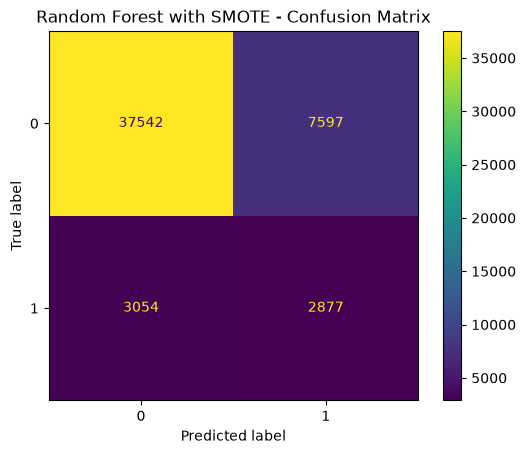

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Random Forest with SMOTE - Confusion Matrix")
plt.show()

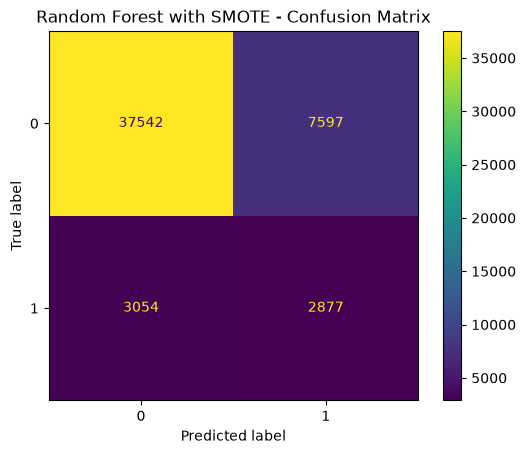

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Random Forest with SMOTE - Confusion Matrix")
plt.show()

In [31]:
# Get feature names after preprocessing

feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print("First 10 features:", feature_names[:10])

Number of features: 31
First 10 features: ['num__Age' 'num__Income' 'num__LoanAmount' 'num__CreditScore'
 'num__MonthsEmployed' 'num__NumCreditLines' 'num__InterestRate'
 'num__LoanTerm' 'num__DTIRatio' "cat__Education_Bachelor's"]


In [32]:
print("Model:", rf_model)
print("Number of model features:", len(rf_model.feature_importances_))

Model: RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)
Number of model features: 31


In [33]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Top 10 Features:")
print(feature_importance.head(10))

Top 10 Features:
                          Feature  Importance
0                        num__Age    0.189372
1               num__InterestRate    0.102291
2   cat__EmploymentType_Full-time    0.081196
3                     num__Income    0.057777
4             num__NumCreditLines    0.050124
5             num__MonthsEmployed    0.048928
6           cat__LoanPurpose_Home    0.047257
7  cat__EmploymentType_Unemployed    0.040252
8                 num__LoanAmount    0.035773
9              cat__Education_PhD    0.031272


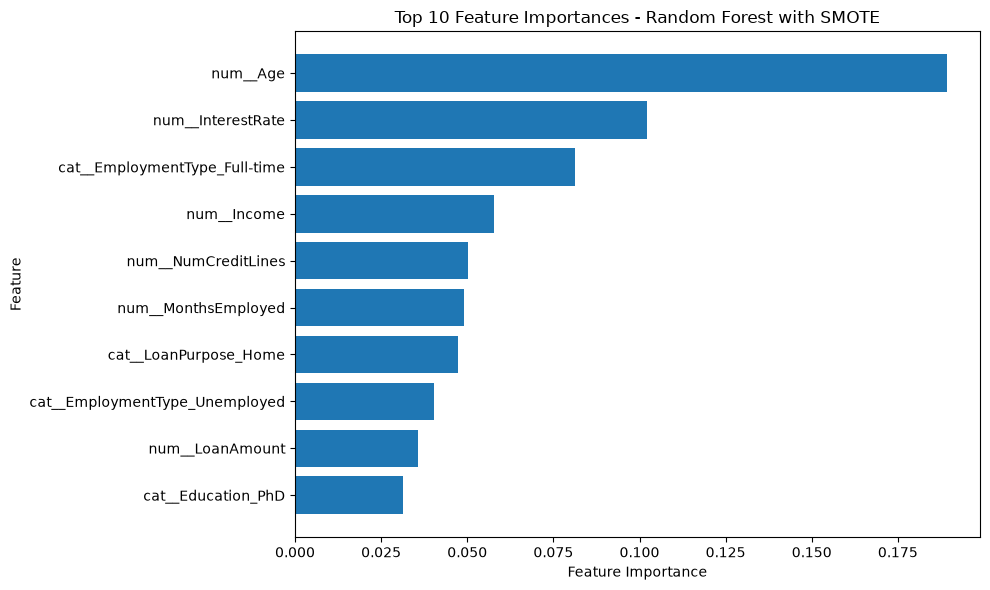

In [34]:
top_10 = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Feature"][::-1],
    top_10["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Random Forest with SMOTE")

plt.tight_layout()
plt.show()

In [36]:
print("Final Model Performance:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Final Model Performance:
Accuracy : 0.7914
Precision: 0.8493
Recall   : 0.7914
F1 Score : 0.8148


In [37]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.83      0.88     45139
           1       0.27      0.49      0.35      5931

    accuracy                           0.79     51070
   macro avg       0.60      0.66      0.61     51070
weighted avg       0.85      0.79      0.81     51070



In [39]:
import joblib

print("joblib imported successfully!")

joblib imported successfully!


In [40]:
joblib.dump(
    rf_model,
    "production_rf_model.pkl"
)

print("Production model saved successfully!")

Production model saved successfully!


In [41]:
joblib.dump(
    preprocessor,
    "preprocessor.pkl"
)

print("Preprocessor saved successfully!")

Preprocessor saved successfully!


In [42]:
import os

print("production_rf_model.pkl:",
      os.path.exists("production_rf_model.pkl"))

print("preprocessor.pkl:",
      os.path.exists("preprocessor.pkl"))

production_rf_model.pkl: True
preprocessor.pkl: True
